# 02 · Feature Engineering & EDA

Sixteen interpretable features are computed at *recall time* (start of the new session) — none peek at future turns. Groups: temporal/structural, speaker, surface/lexical, semantic (SBERT `all-MiniLM-L6-v2`), and recurrence.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd, numpy as np, json
from IPython.display import Image, display
PROC, RES, FIG = ROOT/'data'/'processed', ROOT/'results', ROOT/'reports'/'figures'


In [2]:
from features import FEATURE_COLUMNS
df = pd.read_parquet(PROC/'features_labeled.parquet')
print(len(FEATURE_COLUMNS), 'features'); print(FEATURE_COLUMNS)
df[FEATURE_COLUMNS].describe().T.round(3)

16 features
['recency_sessions', 'turns_since_recall', 'position_in_session', 'role_speaker1', 'sentence_length', 'char_length', 'has_number', 'has_proper_noun', 'is_question', 'first_person_count', 'stopword_ratio', 'tfidf_max', 'tfidf_mean', 'sim_to_current_query', 'persona_salience', 'access_frequency']


,count,mean,std,min,25%,50%,75%,max
recency_sessions,17631.0,2.195,1.012,1.000,1.000,2.000,3.000,4.000
turns_since_recall,17631.0,21.298,13.184,1.000,10.000,20.000,31.000,54.000
position_in_session,17631.0,6.169,4.001,0.000,3.000,6.000,9.000,17.000
role_speaker1,17631.0,0.501,0.500,0.000,0.000,1.000,1.000,1.000
sentence_length,17631.0,18.783,11.937,3.000,10.000,15.000,25.000,106.000
char_length,17631.0,94.438,61.267,14.000,52.000,74.000,125.000,541.000
has_number,17631.0,0.054,0.226,0.000,0.000,0.000,0.000,1.000
has_proper_noun,17631.0,0.166,0.372,0.000,0.000,0.000,0.000,1.000
is_question,17631.0,0.410,0.492,0.000,0.000,0.000,1.000,1.000
first_person_count,17631.0,1.629,1.483,0.000,1.000,1.000,2.000,12.000


## Semantic features
`sim_to_current_query` = cosine(memory, opening query); `persona_salience` = max cosine(memory, carried-forward persona sentences).

In [3]:
df.groupby('label_retain')[['sim_to_current_query','persona_salience','tfidf_max','tfidf_mean','first_person_count']].mean().round(3)

,sim_to_current_query,persona_salience,tfidf_max,tfidf_mean,first_person_count
label_retain,,,,,
0,0.174,0.492,0.561,0.418,1.532
1,0.267,0.583,0.488,0.338,2.152


## Feature distributions by class

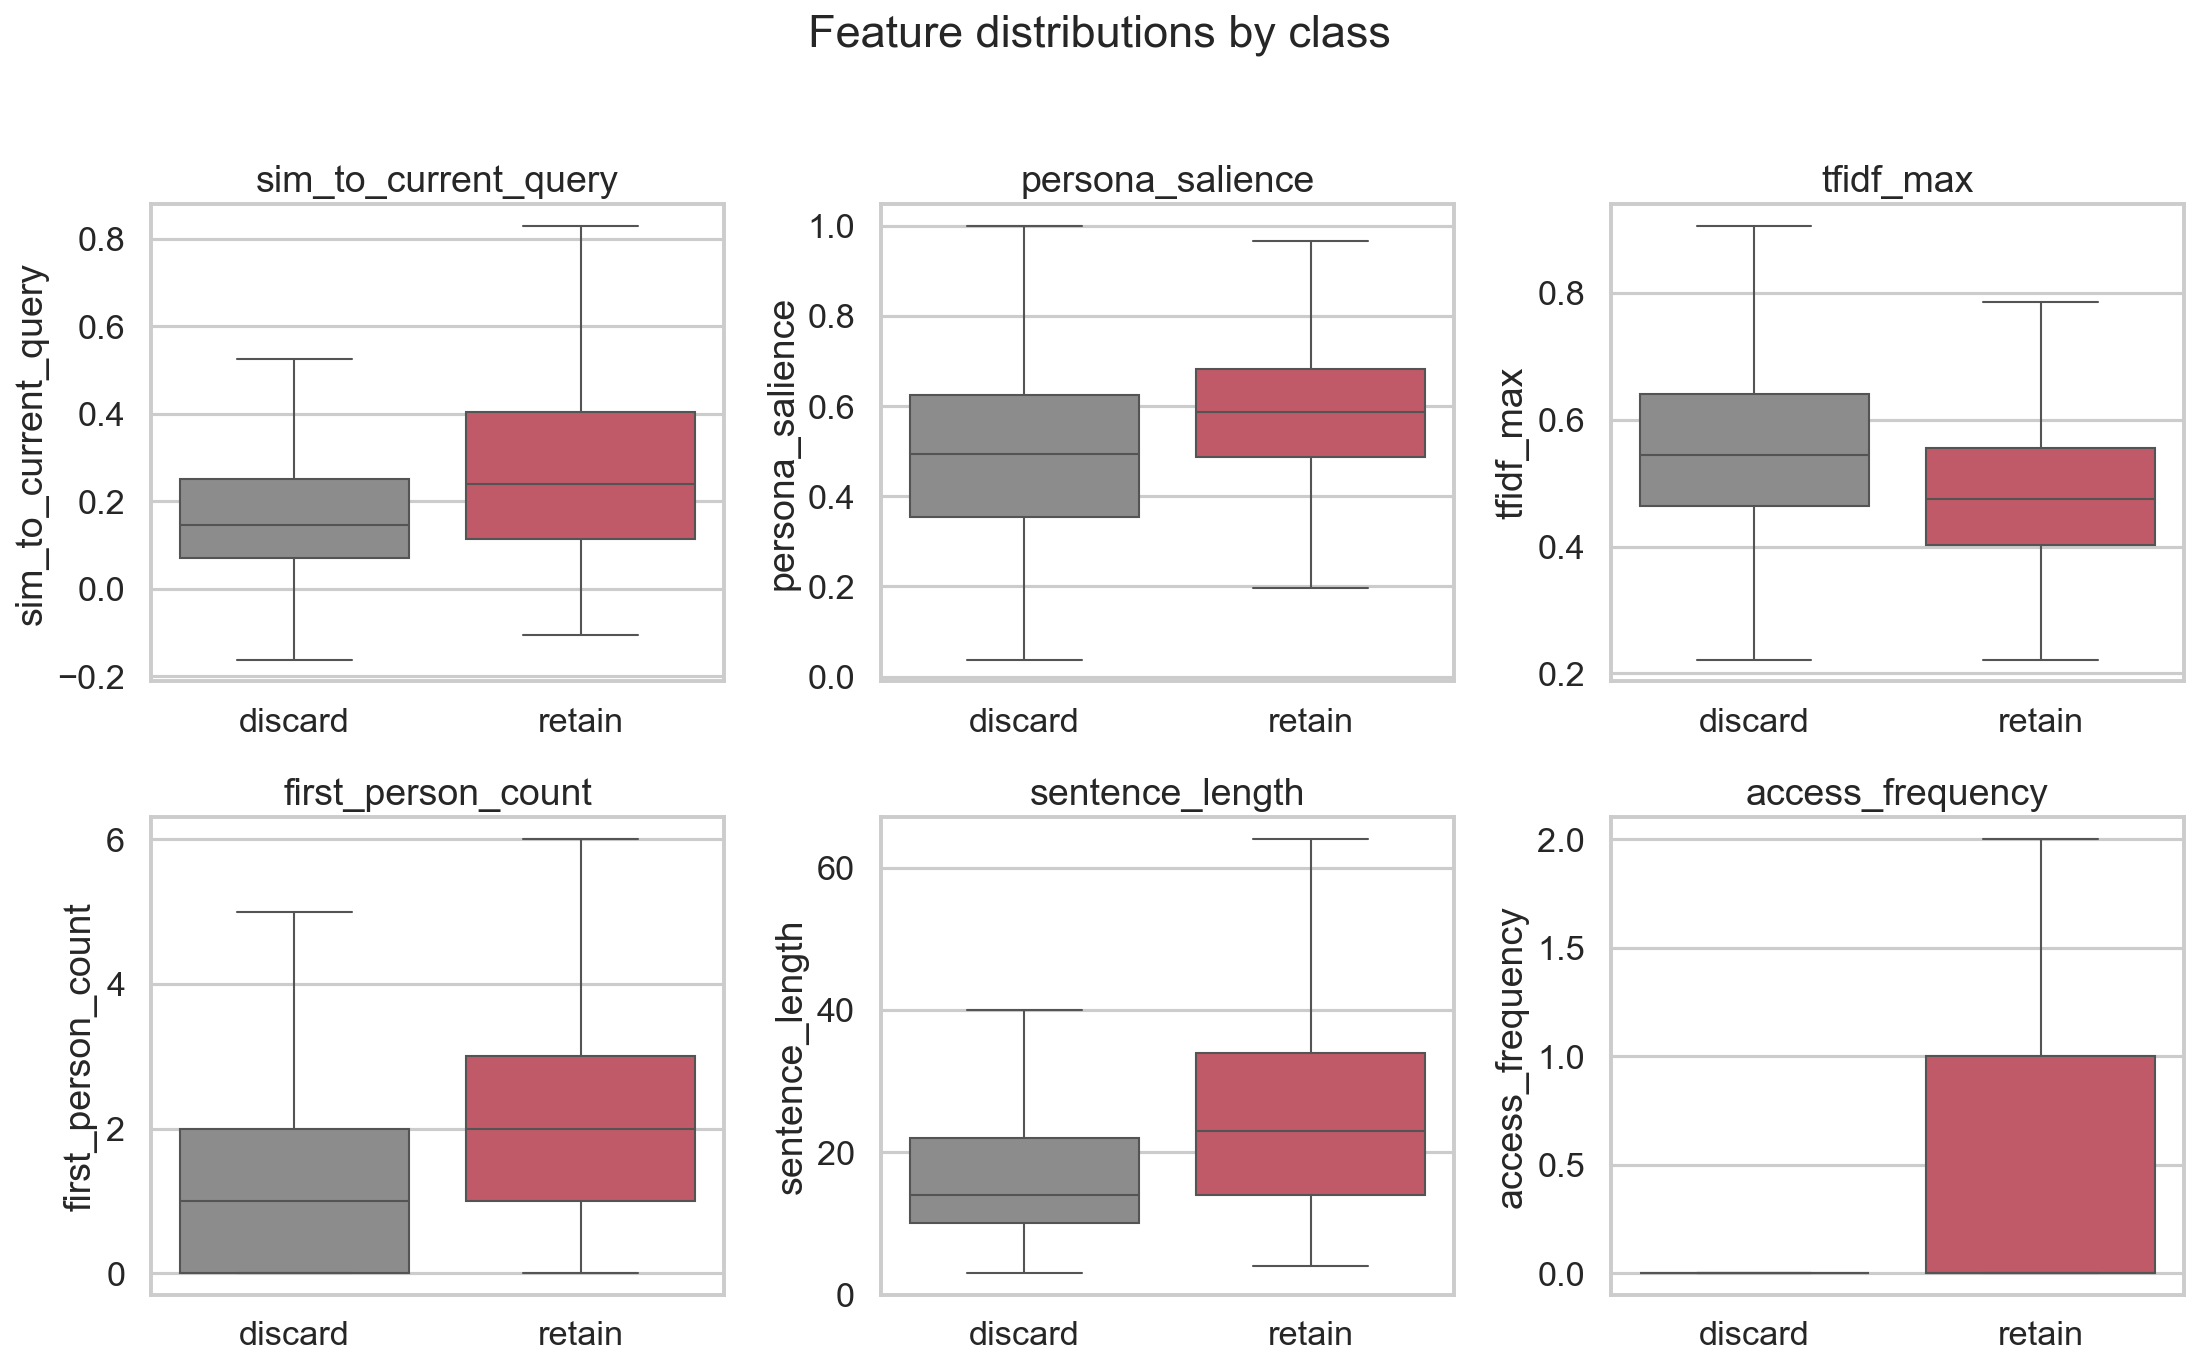

In [4]:
display(Image(str(FIG/'feature_distributions.png')))

## Correlation structure

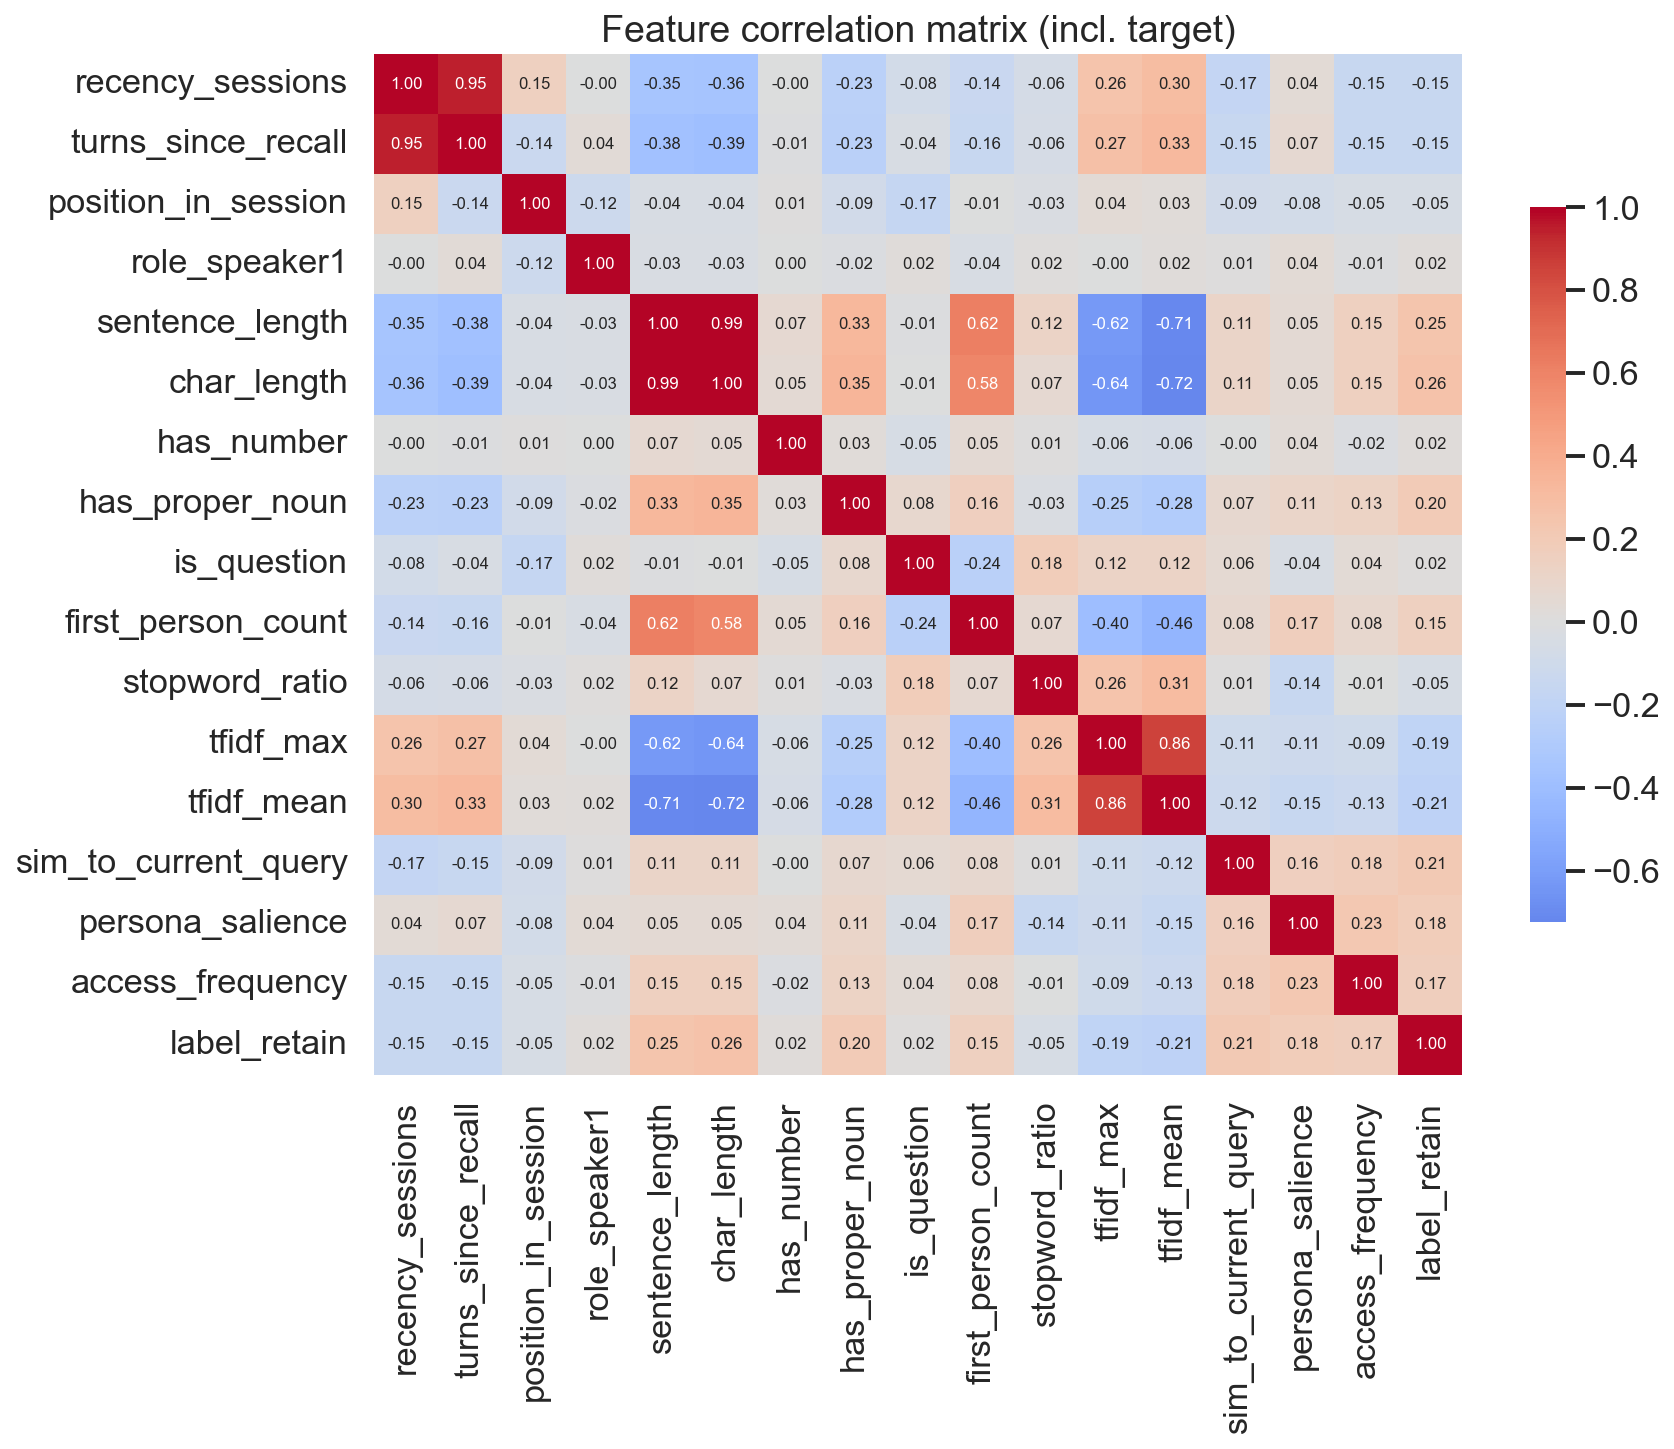

In [5]:
display(Image(str(FIG/'correlation_heatmap.png')))

## Mutual information with the target

MI(X;Y) = Σ p(x,y) log [ p(x,y) / (p(x)p(y)) ]. Specificity features (TF-IDF) and persona-salience are most informative; raw query-similarity ranks lower — an early sign that pure similarity is a weak selector.

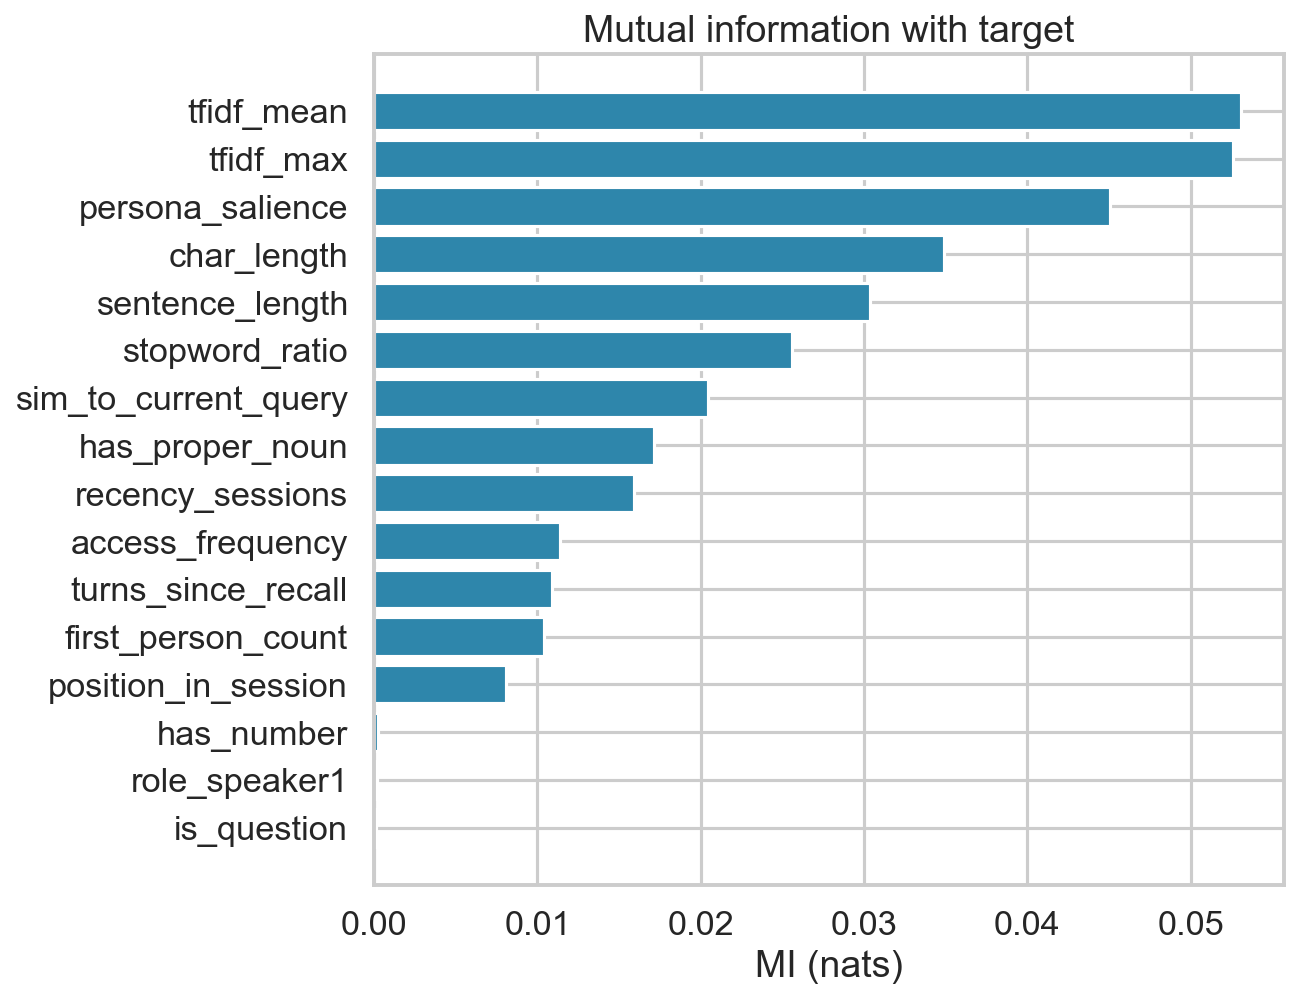

,mutual_information
tfidf_mean,0.0531
tfidf_max,0.0526
persona_salience,0.0450
char_length,0.0349
sentence_length,0.0304
stopword_ratio,0.0256
sim_to_current_query,0.0204
has_proper_noun,0.0172
recency_sessions,0.0159
access_frequency,0.0114


In [6]:
display(Image(str(FIG/'mutual_information.png')))
pd.read_csv(RES/'mutual_information.csv', index_col=0).round(4)

## PCA (dimensionality analysis)

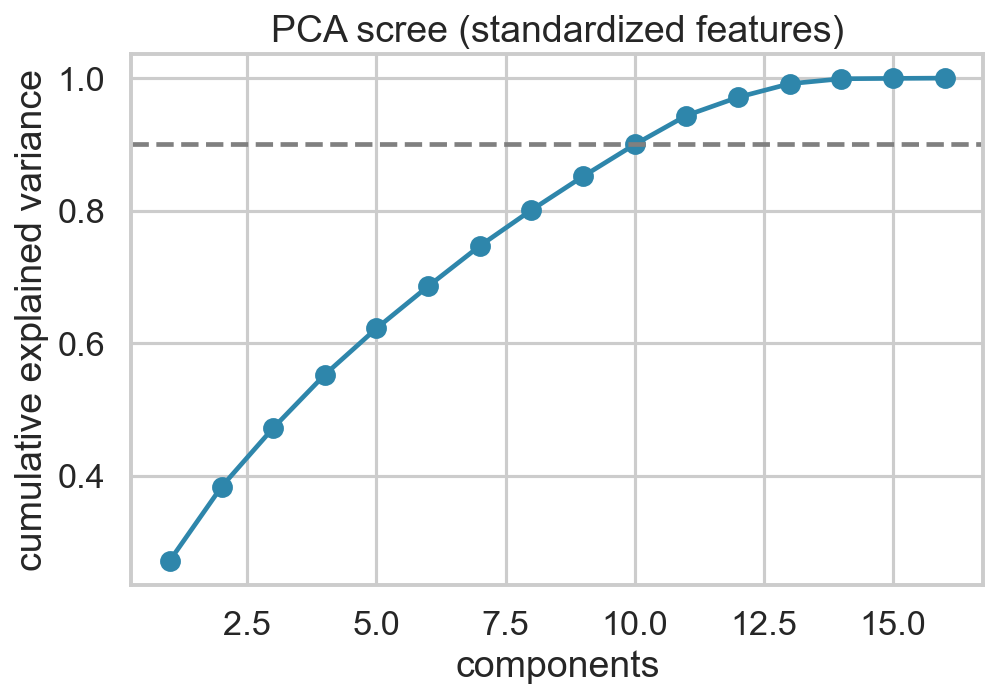

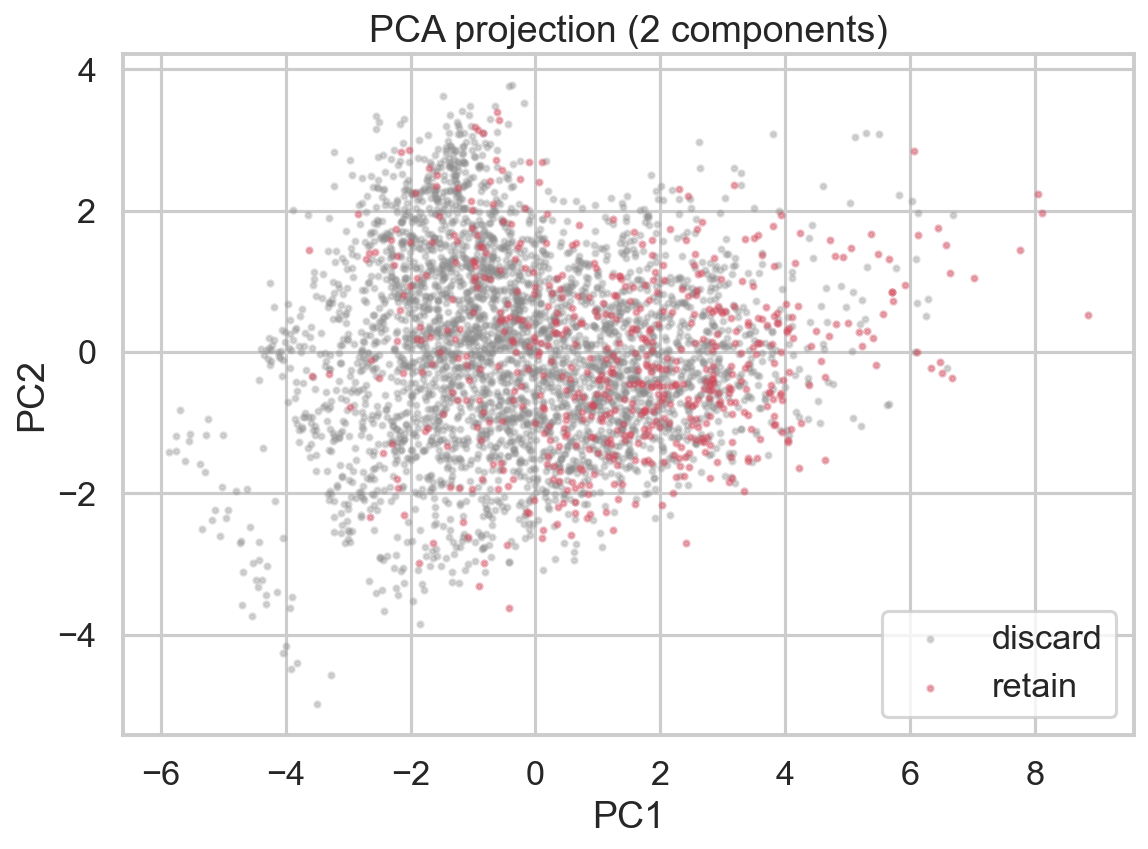

In [7]:
display(Image(str(FIG/'pca_variance.png')))
display(Image(str(FIG/'pca_scatter.png')))